# Fit continuum with X22 built-in function

In [1]:
import numpy as np
from matplotlib import pyplot as plt
import matplotlib as mpl
from matplotlib.colors import ListedColormap
top = mpl.colormaps['Reds_r'].resampled(128)
bottom = mpl.colormaps['Blues'].resampled(128)
newcolors = np.vstack((top(np.linspace(0, 1, 128)),
                       bottom(np.linspace(0, 1, 128))))
residual_cmp = ListedColormap(newcolors, name='RedsBlue')
from matplotlib.patches import Ellipse

In [2]:
import sys
sys.path.insert(0,'../')
from X22_model.disk_model import *
from astropy.coordinates import SkyCoord

In [3]:
fname_band6_stokeI  = '/home/hyp0515/project_data/IRAS16293/image_FITS/ALMA_Band6_Pol/c2d_1008_Stokes.I.regrid.fits'
fname_band6_stokeI_highres = '/home/hyp0515/project_data/IRAS16293/image_FITS/ALMA_Band6_Pol/iras16293B_cont_b6_foralpha_pbcor.fits'
fname_band3_stokeI  = '/home/hyp0515/project_data/IRAS16293/image_FITS/ALMA_Band3_StokesI/sourceB.image.dropdreg.fits'
fname_qband_stokeI  = '/home/hyp0515/project_data/IRAS16293/image_FITS/JVLA_Qband_Pol/iras16293_Qband.rob0.I.regrid.fits'
fname_kuband_stokeI = '/home/hyp0515/project_data/IRAS16293/image_FITS/JVLA_Kuband_Pol/rob0/I16293_Kuband_A.rob0.I.image.tt0.pbcor.subim.fits'
observation_list = [
    # fname_band6_stokeI, 
    # fname_band3_stokeI, 
    fname_qband_stokeI, 
    fname_kuband_stokeI
]
lambda_list = [
    # 0.13, 
    # 0.3, 
    0.7, 
    1.8
] # in cm
sigma_list = [
    # 250e-6, 
    # 17e-6, 
    47e-6, 
    47e-6
] # in Jy/beam
center_list = [
    # (SkyCoord(ra='16:32:22.613', dec='-24:28:32.61', unit=('hourangle', 'deg'))),
    # (SkyCoord(ra='16:32:22.611', dec='-24:28:32.60', unit=('hourangle', 'deg'))),
    (SkyCoord(ra='16:32:22.615', dec='-24:28:32.54', unit=('hourangle', 'deg'))),
    (SkyCoord(ra='16:32:22.613', dec='-24:28:32.68', unit=('hourangle', 'deg'))),
]

In [4]:
def fit(amax):
    opacity_table = generate_opacity_table_opt(
        a_min=1e-6, a_max=amax*1e-4, # min/max grain size
        q=-3.5, # slope for dust size distribution, dn/da ~ a^q
        dust_to_gas=0.01 # dust-to-gas ratio before sublimation
    )
    disk_property_table = generate_disk_property_table(opacity_table=opacity_table)
    D = DiskFitting('CB68', opacity_table, disk_property_table)
    cosI = np.cos(np.deg2rad(50))
    D.set_cosI(cosI=cosI)
    DI_list = []
    for i, fname in enumerate(observation_list):
        # ra_deg, dec_deg, disk_pa = find_center(fname, x_lim=[2750,3250], y_lim=[2750,3250])
        # ra_center  = '16:57:19.6428' # from 2d gaussian fitting"""  """
        # dec_center = '-16:09:24.013'
        # # Convert WCS to pixel coordinates
        coord_center = center_list[i]
        ra_deg, dec_deg = coord_center.ra.degree, coord_center.dec.degree
        DI = DiskImage(
            fname = fname,
            ra_deg = ra_deg,
            dec_deg = dec_deg,
            distance_pc = 140,
            rms_Jy = sigma_list[i],
            img_size_au = 200,
            disk_pa=5,
            remove_background=True
        )
        D.add_observation(DI, lambda_list[i])
        DI_list.append(DI)
    D.fit(weights=None)
    return D, DI_list, amax

In [5]:
D, diskImage, amax = fit(amax=5e2) # um

In [6]:
print('M_star [M_sun] =',D.disk_model.Mstar/Msun)
print('R_disk [au] =',D.disk_model.Rd/au)
print('M_dot [M_sun/yr] =', D.disk_model.Mdot/Msun*yr)

M_star [M_sun] = 4.8630257476246666
R_disk [au] = 33.21007182915261
M_dot [M_sun/yr] = 5.446928486083275e-06


In [7]:
vmax_list = [25, 1.5]

In [8]:
def plot(diskImage):
    fig, ax = plt.subplots(2,3, figsize=(15,10))
    fig.subplots_adjust(left=0.05, right=0.97, top=0.9, bottom=0.1, wspace=0.0, hspace=0.0)

    for i, DI in enumerate(diskImage):


        obs = ax[i, 0].imshow(DI.img*1e3, cmap='jet', origin='lower', vmin=0, vmax=vmax_list[i])
        colorbar = fig.colorbar(obs, ax=ax[i, 0], pad=0.00, aspect=30, shrink=.98)
        colorbar.set_label('Intensity (mJy/beam)')
        ax[i, 0].set_xlabel('AU', fontsize=14)
        ax[i, 0].set_yticks([0, DI.img.shape[0]//2, DI.img.shape[0]-1])
        ax[i, 0].set_yticklabels([-np.round(DI.img_size_au), 0, np.round(DI.img_size_au)])
        ax[i, 0].set_ylabel('AU', fontsize=14)
        ax[i, 0].set_title('Observation', fontsize=14)

        # beam = Ellipse((130, 10), width=DI.beam_min_au/DI.au_per_pix, height=DI.beam_maj_au/DI.au_per_pix,
        #             angle=DI.beam_pa, edgecolor='w', facecolor='w', lw=1.5, fill=True)
        # ax[i, 0].add_patch(beam)


        # ax[0].contour(diskImage.img, levels=[50*40e-6]ors='black', linewidths=0.65)

        model = ax[i, 1].imshow(DI.img_model*1e3, cmap='jet', origin='lower', vmin=0, vmax=vmax_list[i])
        colorbar = fig.colorbar(model, ax=ax[i, 1], pad=0.00, aspect=30, shrink=.98)
        colorbar.set_label('Intensity (mJy/beam)')
        beam = Ellipse((120, 10), width=DI.beam_min_au/DI.au_per_pix, height=DI.beam_maj_au/DI.au_per_pix,
                    angle=DI.beam_pa, edgecolor='w', facecolor='w', lw=1.5, fill=True)
        ax[i, 1].set_xlabel('AU', fontsize=14)
        ax[i, 1].set_yticks([])
        ax[i, 1].set_title('GIdisk model (fitted by built-in)', fontsize=14)

        # beam = Ellipse((130, 10), width=DI.beam_min_au/DI.au_per_pix, height=DI.beam_maj_au/DI.au_per_pix,
        #             angle=DI.beam_pa, edgecolor='w', facecolor='w', lw=1.5, fill=True)
        # ax[i, 1].add_patch(beam)

        residual = ax[i, 2].imshow((DI.img-DI.img_model)*1e3, cmap=residual_cmp, origin='lower', vmin=-0.5*vmax_list[i], vmax=0.5*vmax_list[i])
        colorbar = fig.colorbar(residual, ax=ax[i, 2], pad=0.00, aspect=30, shrink=.98)
        colorbar.set_label('Intensity (mJy/beam)')
        ax[i, 2].set_xticks([0, DI.img.shape[0]//2, DI.img.shape[0]-1])
        ax[i, 2].set_xticklabels([-np.round(DI.img_size_au), 0, np.round(DI.img_size_au)])
        ax[i, 2].set_xlabel('AU', fontsize=14)
        ax[i, 2].set_yticks([])
        ax[i, 2].set_title('Residual', fontsize=14)

        # beam = Ellipse((130, 10), width=DI.beam_min_au/DI.au_per_pix, height=DI.beam_maj_au/DI.au_per_pix,
        #             angle=DI.beam_pa, edgecolor='k', facecolor='k', lw=1.5, fill=True)
        # ax[i, 2].add_patch(beam)

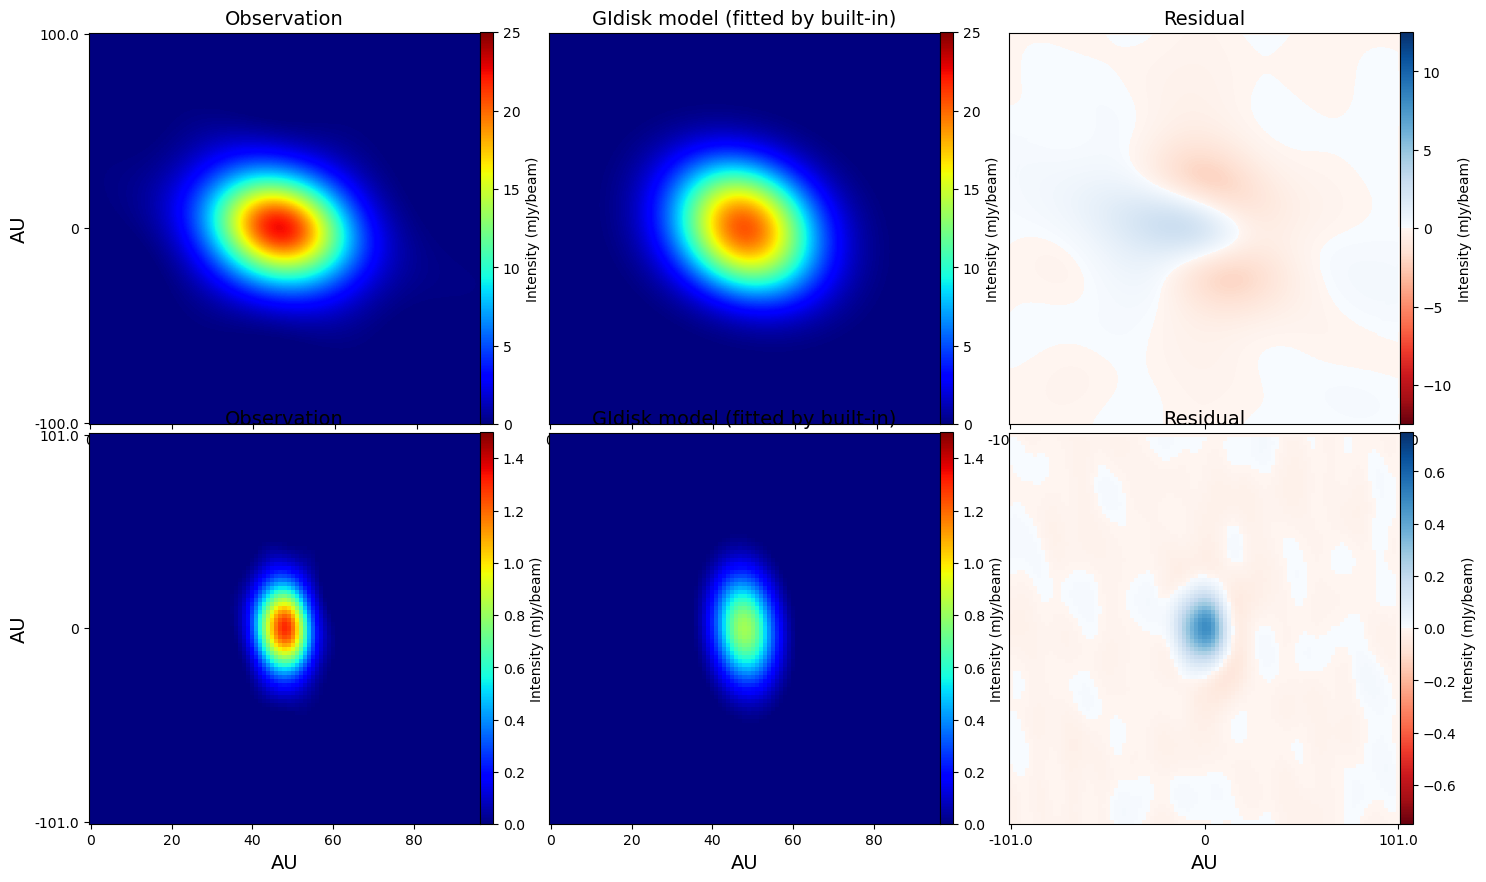

In [9]:

plot(diskImage)